# Expected Value Calculation on IQM

In [1]:
from py4lexis.session import LexisSession
from qaas.client import QProvider, QBackend, QJob


# 1. Authentication
lexis_session = LexisSession()
token = lexis_session.get_access_token()

# 2. Configure resources
PROJECT = "SURFq26"   # e.g. OPEN-37-1
RESOURCE = "VLQ-NL" # e.g. VLQ-CZ

# 3. Initialize QaaS
provider = QProvider(token, PROJECT)
backend:QBackend = provider.get_backend(RESOURCE)


/Users/renau001/Documents/projects/quantum/QuantumBayesianQuadrature/molqbq/.venv_vlq_qiskit145/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Welcome to the Py4LEXIS (v7.0.3)!
Proceeding login via login page...
Open provided url in your browser, please: https:/aai.lexis.tech/auth/realms/LEXIS_AAI_v2/protocol/openid-connect/auth/device?user_code=MCZB-SLJO
Check if user is logged in: Pending.                                            
Check if user is logged in: OK!
You have been successfully logged in LEXIS session.


# Create the encoding circuit

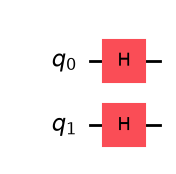

In [ ]:
from qiskit import QuantumCircuit
import numpy as np 
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.primitives import BackendEstimatorV2
from qiskit.primitives import StatevectorEstimator as Estimator


qc = QuantumCircuit(2)
qc.h(0)
qc.h(1)
qc.draw('mpl')

# Create Operators

In [ ]:
# Pauli string
pauli_strings = ['XI','IX']
hamiltonian = [SparsePauliOp(ps) for ps  in pauli_strings]

# Transpile the circuit with VLQ with optimization level 0

In [ ]:
# transpile the circuit and observables
pm0 = generate_preset_pass_manager(backend=backend, optimization_level=0)
qc_transpiled_0 = pm0.run(qc)
obs_transpiled_0 = [h.apply_layout(qc_transpiled_0.layout) for h in hamiltonian]

# Transpile the circuit with VLQ witn optimization level 1

In [110]:
# transpile the circuit and observables
pm1 = generate_preset_pass_manager(backend=backend, optimization_level=1)
qc_transpiled_1 = pm1.run(qc)
obs_transpiled_1 = [h.apply_layout(qc_transpiled_1.layout) for h in hamiltonian]

# Extract StateVector

In [ ]:
# from qiskit.quantum_info import Statevector

# sv = Statevector.from_instruction(qc)
# sv_vql_0 = Statevector.from_instruction(qc_transpiled_0)
# sv_vql_1 = Statevector.from_instruction(qc_transpiled_1)

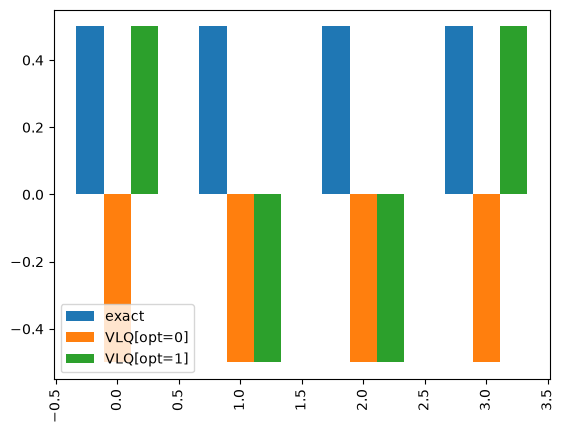

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np 

# xticks = [np.binary_repr(i, width=2) for i in range(4)]

# plt.grouped_bar({'exact':sv.data.real, 'VLQ[opt=0]':sv_vql_0.data[:4].real, 'VLQ[opt=1]':sv_vql_1.data[:4].real})
# plt.tick_params("x", rotation=90, rotation_mode="xtick")
# plt.legend()

# Create the estimator 

In [113]:
# start the estimator
estimator = BackendEstimatorV2(backend=backend)
exact_estimator = Estimator()

# Calculation of the expectation values

In [ ]:
def compute_expectation(backend_estimator, quantum_circuit, obs):
    """Compute the expectation of the circuit/observalbe

    Args:
        backend_estimator: The estimator to use
        quantum_circuit: The quantum circuit for which to compute expectations
        obs: The observables for which to compute expectations

    Returns:
        List: A list of expectation values
    """
    evs = []
    for _obs in obs:
        job = backend_estimator.run([(quantum_circuit, _obs)], precision=0.02)
        pub_result = job.result()
        evs.append(pub_result[0].data.evs)
    return evs

In [132]:
ev_exact = compute_expectation(exact_estimator, qc, hamiltonian)

In [135]:
ev_opt0 = compute_expectation(estimator, qc_transpiled_0, obs_transpiled_0)

In [133]:
ev_opt1 = compute_expectation(estimator, qc_transpiled_1, obs_transpiled_1)

# Compare results

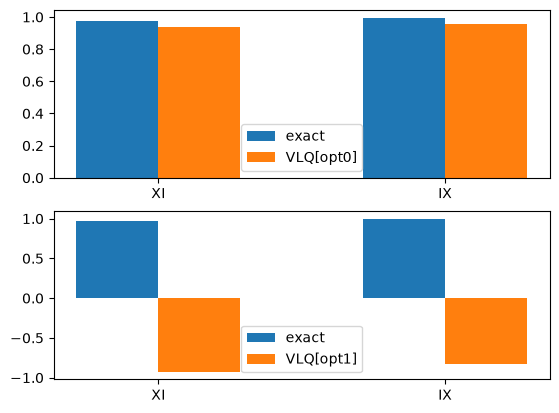

In [139]:
import matplotlib.pyplot as plt

plt.subplot(211)
plt.grouped_bar({'exact':ev_exact, 'VLQ[opt0]':ev_opt0}, tick_labels=pauli_strings)
plt.legend()

plt.subplot(212)
plt.grouped_bar({'exact':ev_exact, 'VLQ[opt1]':ev_opt1}, tick_labels=pauli_strings)
plt.legend()
